In [1]:
pip install opencv-python --no-deps

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install "numpy>2"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


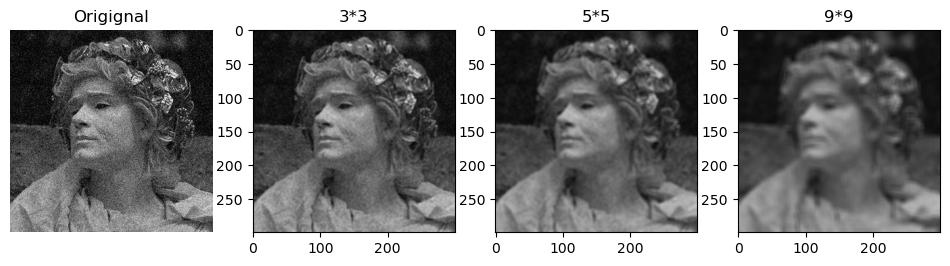

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def box_filt(image, k):
    return cv2.blur(image,(k,k))

img = cv2.imread("/Users/230107/Downloads/man.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blur3 = box_filt(img, 3)
blur5 = box_filt(img, 5)
blur9 = box_filt(img, 9)

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Origignal")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(blur3)
plt.title("3*3")

plt.subplot(1,4,3)
plt.imshow(blur5)
plt.title("5*5")

plt.subplot(1,4,4)
plt.imshow(blur9)
plt.title("9*9")

plt.show()



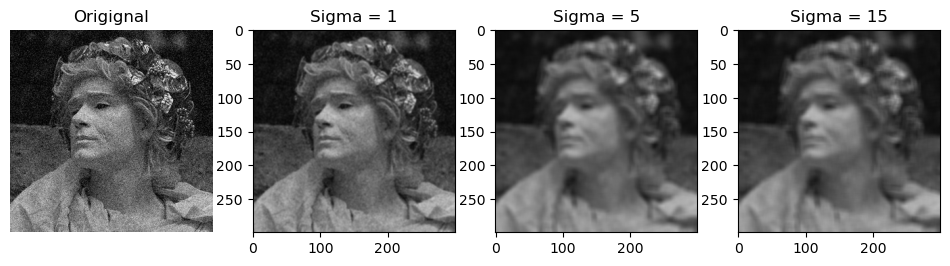

In [2]:
g1 = cv2.GaussianBlur(img,(9,9),1)
g5 = cv2.GaussianBlur(img,(9,9),5)
g15 = cv2.GaussianBlur(img,(9,9),15)

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Origignal")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(g1)
plt.title("Sigma = 1")

plt.subplot(1,4,3)
plt.imshow(g5)
plt.title("Sigma = 5")

plt.subplot(1,4,4)
plt.imshow(g15)
plt.title("Sigma = 15")

plt.show()

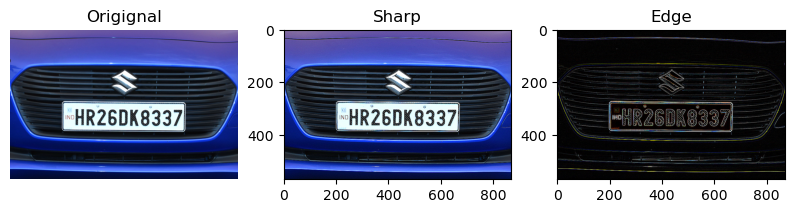

In [6]:
img = cv2.imread("/Users/230107/Downloads/num.jpg")

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharp = cv2.filter2D(img,-1,sharpen_kernel)

edge_kernel = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

edge = cv2.filter2D(img,-1,edge_kernel)

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Origignal")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sharp)
plt.title("Sharp")

plt.subplot(1,3,3)
plt.imshow(edge)
plt.title("Edge")

plt.show()

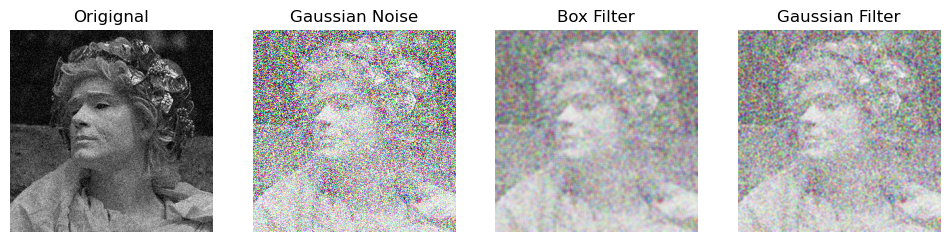

In [8]:
img = cv2.imread("/Users/230107/Downloads/man.jpg")

noise = np.random.normal(0,25,img.shape).astype(np.uint8)
gaussian_noise = cv2.add(img, noise)

sp = img.copy()
prob = 0.02

rand = np.random.rand(*img.shape[:2])

sp[rand < prob] = 0
sp[rand > 1-prob] = 255

box_filter = cv2.blur(gaussian_noise,(5,5))
gauss_filter = cv2.GaussianBlur(gaussian_noise,(5,5),1)

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Origignal")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gaussian_noise)
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(box_filter)
plt.title("Box Filter")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(gauss_filter)
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

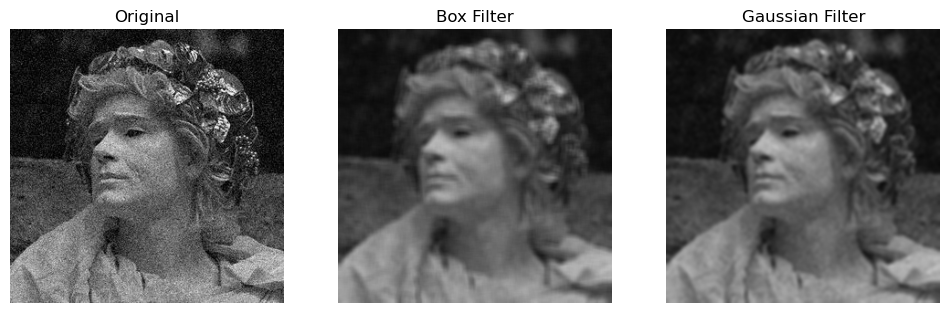

In [9]:
box_blur = cv2.blur(img,(7,7))
gauss_blur = cv2.GaussianBlur(img,(7,7),2)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(box_blur)
plt.title("Box Filter")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gauss_blur)
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()


Edge intensity Original: 33.38556666666667
Edge intensity Box filter: 2.1425
Edge intensity Gaussian filter: 2.593488888888889


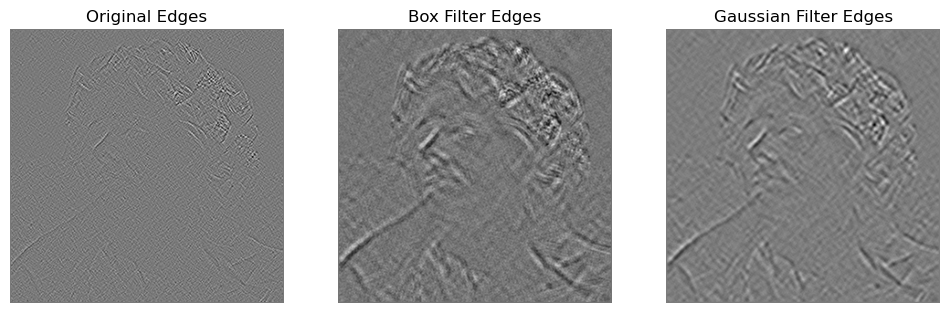

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray_box = cv2.cvtColor(box_blur, cv2.COLOR_RGB2GRAY)
gray_gauss = cv2.cvtColor(gauss_blur, cv2.COLOR_RGB2GRAY)

edge_original = cv2.Sobel(gray, cv2.CV_64F,1,1,ksize=3)
edge_box = cv2.Sobel(gray_box, cv2.CV_64F,1,1,ksize=3)
edge_gauss = cv2.Sobel(gray_gauss, cv2.CV_64F,1,1,ksize=3)

print("Edge intensity Original:", np.mean(np.abs(edge_original)))
print("Edge intensity Box filter:", np.mean(np.abs(edge_box)))
print("Edge intensity Gaussian filter:", np.mean(np.abs(edge_gauss)))

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(edge_original, cmap='gray')
plt.title("Original Edges")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(edge_box, cmap='gray')
plt.title("Box Filter Edges")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edge_gauss, cmap='gray')
plt.title("Gaussian Filter Edges")
plt.axis("off")

plt.show()


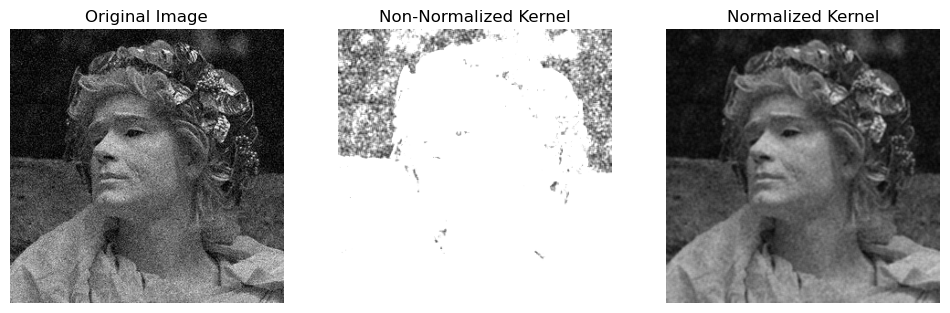

In [11]:
kernel = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])

not_normalized = cv2.filter2D(img, -1, kernel)

normalized_kernel = kernel / np.sum(kernel)

normalized_image = cv2.filter2D(img, -1, normalized_kernel)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(not_normalized)
plt.title("Non-Normalized Kernel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(normalized_image)
plt.title("Normalized Kernel")
plt.axis("off")

plt.show()

Choose filter:
1 - Uniform filter
2 - Gaussian filter


Enter option:  1
Enter kernel size (odd number):  3


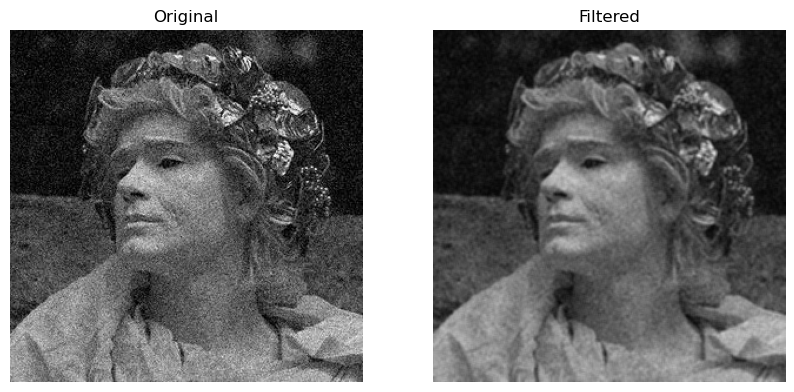

In [13]:
print("Choose filter:")
print("1 - Uniform filter")
print("2 - Gaussian filter")

choice = int(input("Enter option: "))

k = int(input("Enter kernel size (odd number): "))

if choice == 1:
    filtered = cv2.blur(img,(k,k))

elif choice == 2:
    sigma = float(input("Enter sigma: "))
    filtered = cv2.GaussianBlur(img,(k,k),sigma)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(filtered)
plt.title("Filtered")
plt.axis("off")

plt.show()